In [1]:
import pynapple as nap
from pathlib import Path

nwb_path = Path("/data_store2/neuropixels/nwb/NP95_B1/NP95_B1.nwb")
data = nap.load_file(nwb_path)
print(data)

NP95_B1
┍━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                    │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ TaskTimes               │ IntervalSet │
│ TaskStims               │ IntervalSet │
│ StimSpeechWords         │ IntervalSet │
│ StimSpeechTrials        │ IntervalSet │
│ StimSpeechPhones        │ IntervalSet │
│ ProdSpeechWords         │ IntervalSet │
│ ProdSpeechTrials        │ IntervalSet │
│ ProdSpeechPhones        │ IntervalSet │
│ KilosortSortTimes       │ IntervalSet │
│ pitch                   │ TsdFrame    │
│ intensity               │ TsdFrame    │
│ artics_new              │ TsdFrame    │
│ artics                  │ TsdFrame    │
│ NP95_B1_g0_imec1        │ TsGroup     │
│ TimeSeriesNIDQ          │ TsdFrame    │
│ ElectricalSeriesLFImec1 │ TsdFrame    │
│ ElectricalSeriesLFImec0 │ TsdFrame    │
│ Denoised Mic (.wav)     │ Tsd         │
┕━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


In [2]:
key = "NP95_B1_g0_imec1"
spike_times = data[key]

In [3]:
import numpy as np
from scipy.stats import kstest

# 1. filter to good neurons
firingRates_all = spike_times.metadata["rate"]
task_times = data["TaskTimes"]
beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
spike_times_beh = spike_times.restrict(beh_epochs)
firingRates_beh = spike_times_beh.metadata["rate"]

# calculate ks stats
start_time = task_times.start
end_time = task_times.end
ks_stats = np.zeros(len(spike_times))
ks_pvals = np.zeros(len(spike_times))
for u in range(len(spike_times)):
    # get spike times for this unit
    test = spike_times[u].as_series().index.values

    # The null hypothesis is that the spike times are uniformly distributed between start_time and end_time
    if len(test) > 1:
        min_time = start_time[0]
        max_time = end_time[-1]
        # Normalize spike times to [0, 1] for KS test against uniform
        normalized_spike_times = (test - min_time) / (max_time - min_time)
        ks_result = kstest(normalized_spike_times, 'uniform')
        ks_stats[u] = ks_result.statistic
        ks_pvals[u] = ks_result.pvalue
    else:
        ks_stats[u] = np.nan
        ks_pvals[u] = np.nan

# now do ISI calculation
violationThreshold = 3/1000 #for 3 ms isi refractory period, what used before, middle of range that kilosort cites
violationPct = np.zeros(len(spike_times))
for u in range(len(spike_times)):
    unit = spike_times[u]
    unit = unit.as_series().index
    if len(unit) < 100:
        violationPct[u] = 1 
    else:
        isi = unit.diff()[1:len(unit)]
        violations = np.where(isi<violationThreshold)
        violations = np.array(violations)
        violationPct[u] = violations.size/len(isi)

# now apply masks
if "KSLabel" in spike_times.metadata:
    KSLabels = spike_times.metadata["KSLabel"]
else:
    KSLabels = spike_times.metadata["quality"]
firingRates = firingRates_beh
mask1 = violationPct<3/100 # throwing out neurons with > 3% isi violations with isi = 3 ms; lose quite a bit with 5 ms esp when including cdf stats
mask2 = firingRates>0.5 # firing rate > 0.5 ms during all behavior epochs
mask3 = KSLabels!="noise" # not noise per auto label
mask4 = ks_stats < 0.3 # KS stat < 0.3 (stability across recording)
mask = mask1 & mask2 & mask3 & mask4
indicesFinal = firingRates.index[mask]
spike_times_good = spike_times_beh[indicesFinal]
print(f"Number of good neurons: {len(spike_times_good)}")

/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 57


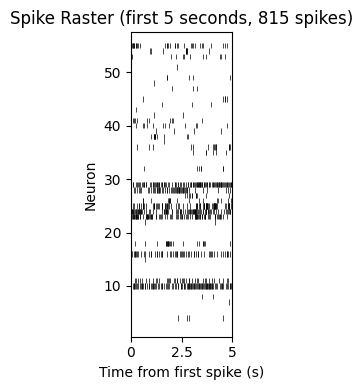

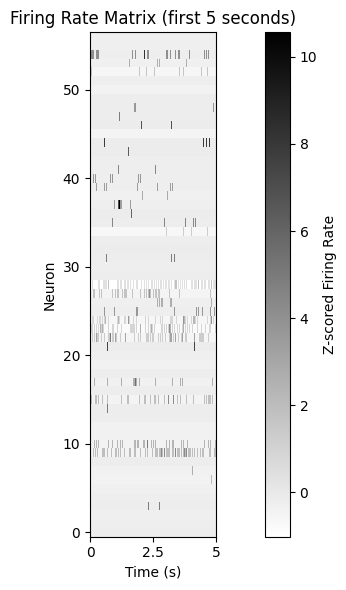

In [4]:
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['svg.fonttype'] = 'none' 

pba = 3

# 2.  make spike rate matrix
# now restrict spike times to the good neurons
spike_times_good = spike_times[indicesFinal]
# print(spike_times_good)

# make spike count matrix
timescale = 25/1000
spikeCountMatrix = spike_times_good.count(bin_size=timescale)
spikeCountMatrix = spikeCountMatrix.values # matrix in spike counts
firingRateMatrix = spikeCountMatrix/timescale # matrix in Hz
firingRateMatrix = stats.zscore(firingRateMatrix, axis=0) # zscore across time (within neuron)

# Plot spike raster for first 5 seconds (normalized so first spike is at time 0)
fig, ax = plt.subplots(figsize=(10, 4))

# Find the earliest spike time across all neurons to use as time zero
min_spike_time = np.inf
for neuron_idx in indicesFinal:
    st = spike_times_good[neuron_idx]
    spike_times_sec = st.as_series().index
    if len(spike_times_sec) > 0:
        min_spike_time = min(min_spike_time, spike_times_sec.min())


# Set time window relative to first spike
t0 = min_spike_time
t1 = min_spike_time + 5

# To ensure both plots have the same neuron order, define a consistent neuron order.
# We'll use the order in which neurons appear in indicesFinal (which is the order in spike_times_good and firingRateMatrix columns).

# Get spike times for good neurons
total_spikes_plotted = 0
n_neurons = len(spike_times_good)
# The neuron order for both plots will be: indicesFinal as a list
neuron_order = list(indicesFinal)

for plot_idx, neuron_idx in enumerate(neuron_order):
    # st is a pynapple Ts object; get times in seconds
    st = spike_times_good[neuron_idx]
    spike_times_sec = st.as_series().index
    # restrict to first 5 seconds after first spike
    spike_times_plot = spike_times_sec[(spike_times_sec >= t0) & (spike_times_sec < t1)]
    if len(spike_times_plot) > 0:
        # Normalize so first spike is at time 0
        spike_times_normalized = spike_times_plot - min_spike_time
        # Flip the neuron order so neuron 0 is at the top
        flipped_idx = n_neurons - plot_idx - 1
        ax.vlines(spike_times_normalized, flipped_idx + 0.5, flipped_idx + 1.5, color='k', linewidth=0.5)
        total_spikes_plotted += len(spike_times_plot)

ax.set_ylabel('Neuron')
ax.set_xlabel('Time from first spike (s)')
ax.set_title(f'Spike Raster (first 5 seconds, {total_spikes_plotted} spikes)')
ax.set_ylim(0.5, n_neurons + 0.5)
ax.set_xlim(0, 5)
# Only show 0, 2.5, 5 on the x axis
ax.set_box_aspect(pba)  # Set the plot box aspect ratio to 2 (width:height = 2:1)
ax.set_xticks([0, 2.5, 5])
ax.set_xticklabels(['0', '2.5', '5'])
plt.tight_layout()
plt.savefig("spike_raster.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Plot firing rate matrix for first 5 seconds
# firingRateMatrix shape: (time_bins, neurons)
# Need to get time bins corresponding to first 5 seconds
n_bins_5s = int(5 / timescale)
# To match the neuron order in the raster, flip the neuron axis (rows) so neuron 0 is at the top
# firingRateMatrix columns correspond to neuron_order; so flip vertically for plotting
frmat_plot = firingRateMatrix[:n_bins_5s, :].T  # shape: (neurons, time_bins)
frmat_plot = np.flipud(frmat_plot)  # flip so neuron 0 is at the top

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(frmat_plot, aspect='auto', cmap='gray_r', interpolation='nearest', vmin=np.min(frmat_plot), vmax=np.max(frmat_plot))

ax.set_ylabel('Neuron')
ax.set_xlabel('Time (s)')
ax.set_title('Firing Rate Matrix (first 5 seconds)')

# Set x-ticks to 0, 2.5, 5 seconds
xticks_sec = [0, 2.5, 5]
xticks_bins = [int(x / timescale) for x in xticks_sec]
ax.set_xticks(xticks_bins)
ax.set_xticklabels([str(x) for x in xticks_sec])

cbar = plt.colorbar(im, ax=ax, label='Z-scored Firing Rate')
ax.set_box_aspect(pba+1)  # Set the plot box aspect ratio to 2 (width:height = 2:1)
ax.invert_yaxis()  # Invert the y axis so neuron 0 is at the top
plt.tight_layout()
plt.savefig("firing_rate_matrix.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()



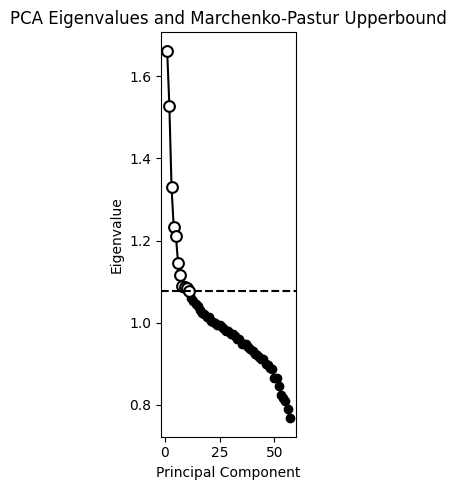

In [5]:
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
from scipy.linalg import norm

plt.rcParams['svg.fonttype'] = 'none' 

# 3. run PCA to get first pass assembly patterns
pca = PCA()

# fit and transform data
# note don't have to center bc each row is zscores so center of matrix is 0
firingRateMatrix_pca = pca.fit_transform(firingRateMatrix)
eigenvalues = pca.explained_variance_

# calculate the upperbound of the Marchenko-Pastur law, eigenvalues above the 
# upper bound are patterns that will be considered "assemblies"
upperbound = (1 + np.sqrt(firingRateMatrix.shape[1] / firingRateMatrix.shape[0])) ** 2

# classic definition
assemblyIndices = np.where(eigenvalues > upperbound)

# more stringent definition
# assemblyIndices = np.where((eigenvalues > upperbound) & (eigenvalues > np.mean(eigenvalues) + np.std(eigenvalues) * 2))

# save assembly eigenvalues
assemblyEigenvalues = eigenvalues[assemblyIndices]

plt.figure(figsize=(8, 5))
xvals = np.arange(1, len(eigenvalues) + 1)
# Plot all eigenvalues as black points
plt.plot(xvals, eigenvalues, color='black', marker='o', linestyle='-', label='Eigenvalues', zorder=1)

# Highlight values above upperbound as white with black border, same size
above = eigenvalues > upperbound
plt.scatter(xvals[above], eigenvalues[above], 
            facecolor='white', edgecolor='black', s=60, linewidth=1.5, zorder=2, label='Above Upperbound')

plt.axhline(upperbound, color='black', linestyle='--', label=f'Upperbound ({upperbound:.2f})')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('PCA Eigenvalues and Marchenko-Pastur Upperbound')
ax = plt.gca()
ax.set_box_aspect(3)  # Set the plot box aspect ratio to 3 (width:height = 3:1)
plt.tight_layout()
plt.savefig("eigenvalues.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()



Number of assembly patterns: 11


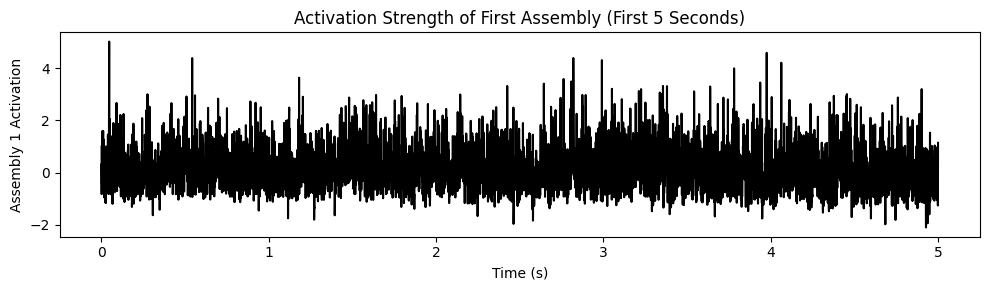

(39795, 11)
(39795, 57)
1.885495989352094e-16
0.9999999999999998


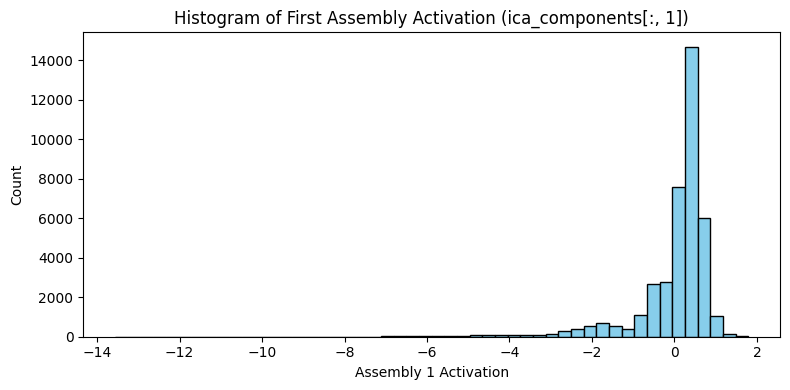

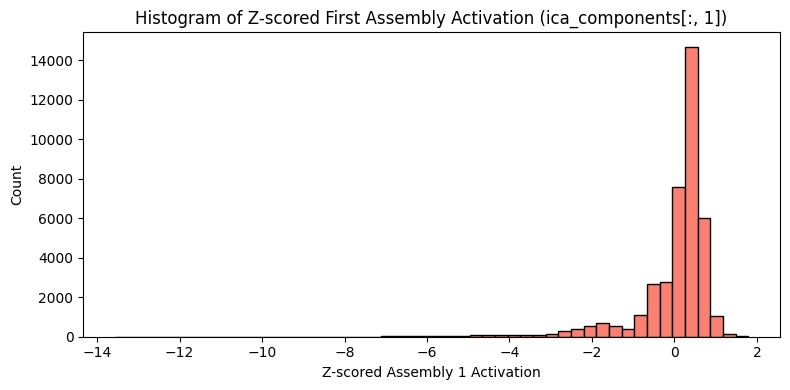

In [6]:
# Do ICA then project back to neuron space for pattern visualization
n_pcs = len(assemblyEigenvalues)
pc_vectors = pca.components_[:n_pcs, :]
print(f"Number of assembly patterns: {n_pcs}")

projections = firingRateMatrix @ pc_vectors.T

# define and run the ICA
if n_pcs > 0:
    fastica = FastICA(
        n_components=n_pcs,
        algorithm='parallel',
        whiten='unit-variance',
        max_iter=500,
        tol=1e-7,
        random_state=1
    )
    ica_components = fastica.fit_transform(projections)

    # get mixing and unmixing matrices
    mixing_matrix = fastica.mixing_
    unmixing_matrix = fastica.components_

    # project the assembly patterns back to the original feature space (neurons)
    ica_assembly_patterns = unmixing_matrix @ pc_vectors  # Shape: (n_pcs, n_features)

    # define members, save out unit vectors and bool in matrices
    ap_norm_matrix = np.zeros_like(ica_assembly_patterns)
    ap_norm_member = np.zeros(ica_assembly_patterns.shape)
    for ii in range(n_pcs):
        ap = ica_assembly_patterns[ii, :]
        ap_norm = ap / norm(ap)
        maxW = max(ap_norm)
        minW = min(ap_norm)
        if abs(minW) > maxW:
            ap_norm = ap_norm * -1
        ap_norm_matrix[ii, :] = ap_norm
        threshold = np.mean(ap_norm) + np.std(ap_norm) * 2
        for c in range(len(ap)):
            if ap_norm[c] > threshold:
                ap_norm_member[ii, c] = 1

    # Plot the activation strength of the first assembly over the first 5 seconds
    # Assume firingRateMatrix rows are time bins, and time is in 'time' variable (in seconds)
    # If not, create a time vector assuming uniform bins
    if 'time' in locals():
        time_vector = time
    else:
        # Assume 1 ms bins if not specified
        dt = 1.0  # ms
        if 'bin_size' in locals():
            dt = bin_size
        elif 'binSize' in locals():
            dt = binSize
        elif 'bin_width' in locals():
            dt = bin_width
        elif 'binWidth' in locals():
            dt = binWidth
        else:
            dt = 1.0  # fallback
        dt = float(dt) / 1000.0  # convert ms to seconds if needed
        time_vector = np.arange(firingRateMatrix.shape[0]) * dt

    # Get the activation of the first assembly (first ICA component)
    first_assembly_activation = ica_components[:, 1]

    # Find indices corresponding to the first 5 seconds
    idx_5s = np.where(time_vector <= 5)[0]

    plt.figure(figsize=(10, 3))
    plt.plot(time_vector[idx_5s], first_assembly_activation[idx_5s], color='black')
    plt.xlabel('Time (s)')
    plt.ylabel('Assembly 1 Activation')
    plt.title('Activation Strength of First Assembly (First 5 Seconds)')
    plt.tight_layout()
    plt.show()

print(ica_components.shape)
print(firingRateMatrix.shape)
print(np.mean(ica_components[:, 2]))
print(np.std(ica_components[:, 2]))

plt.figure(figsize=(8, 4))
plt.hist(ica_components[:, 2], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Assembly 1 Activation')
plt.ylabel('Count')
plt.title('Histogram of First Assembly Activation (ica_components[:, 1])')
plt.tight_layout()
plt.show()

from scipy.stats import zscore

# Z-score the first assembly activation
ica1_z = zscore(ica_components[:, 2])

plt.figure(figsize=(8, 4))
plt.hist(ica1_z, bins=50, color='salmon', edgecolor='black')
plt.xlabel('Z-scored Assembly 1 Activation')
plt.ylabel('Count')
plt.title('Histogram of Z-scored First Assembly Activation (ica_components[:, 1])')
plt.tight_layout()
plt.show()



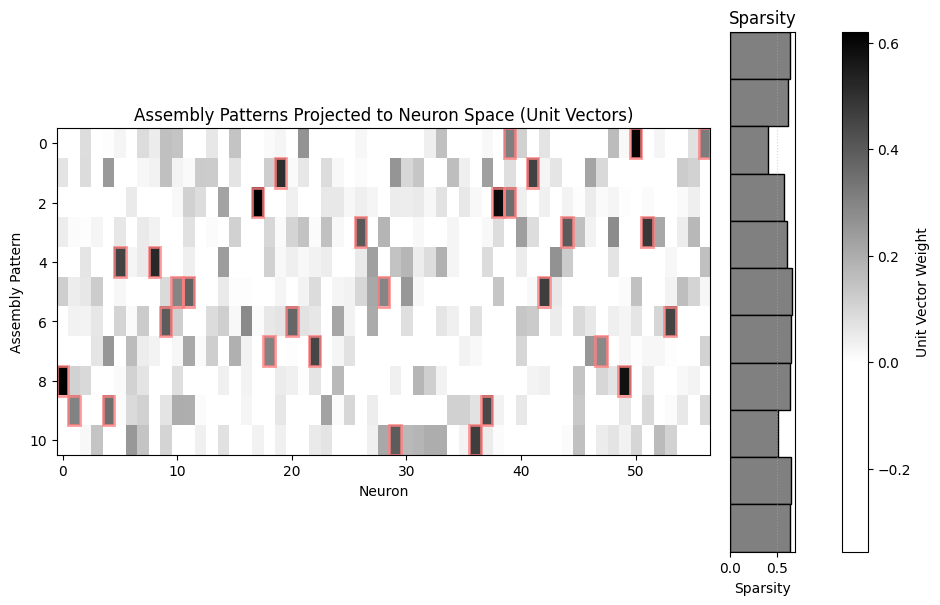

In [48]:
# Custom colormap: negative values are all white, positive values go from white to black
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['svg.fonttype'] = 'none' 

# Find the min and max of the data to set color mapping
vmin = np.min(ap_norm_matrix)
vmax = np.max(ap_norm_matrix)
# Only positive values will be mapped to black, negatives to white
# We'll use a custom colormap with a sharp transition at zero

# Create a colormap: all values <= 0 are white, >0 go from white to black
n_shades = 256
# The first half (for negative and zero) is all white, the second half is white to black
# Find the split index for zero
if vmax > 0:
    zero_split = int(n_shades * (0 - vmin) / (vmax - vmin)) if vmax != vmin else 0
    zero_split = np.clip(zero_split, 0, n_shades-1)
else:
    zero_split = n_shades-1  # all white if all values <= 0

colors = np.ones((n_shades, 4))  # RGBA, all white
if vmax > 0 and zero_split < n_shades-1:
    # Fill the positive part with a white-to-black gradient
    for i in range(zero_split+1, n_shades):
        frac = (i - zero_split) / (n_shades - zero_split - 1)
        colors[i, :3] = 1 - frac  # from white to black

custom_cmap = ListedColormap(colors)

# Set norm so that 0 is at the split
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(10, max(2, n_pcs * 0.5)))
im = ax.imshow(ap_norm_matrix, aspect='auto', cmap=custom_cmap, norm=norm, interpolation='nearest')
plt.colorbar(im, label='Unit Vector Weight', ax=ax)
ax.set_xlabel('Neuron')
ax.set_ylabel('Assembly Pattern')
ax.set_title('Assembly Patterns Projected to Neuron Space (Unit Vectors)')
ax.set_box_aspect(0.5)  # Set plot box aspect ratio to 3 (width:height = 3:1)
plt.tight_layout()

# Calculate the threshold for each row
row_thresholds = np.mean(ap_norm_matrix, axis=1) + np.std(ap_norm_matrix, axis=1) * 2
# Loop through each cell and draw a rectangle if above threshold
for i in range(ap_norm_matrix.shape[0]):
    for j in range(ap_norm_matrix.shape[1]):
        if ap_norm_matrix[i, j] > row_thresholds[i]:
            rect = patches.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                linewidth=2,
                edgecolor=(1, 0.5, 0.5, 0.8),  # light red, semi-transparent
                facecolor='none'
            )
            ax.add_patch(rect)

# Calculate sparsity for each assembly pattern (row)
sparsity_list = []
for ap in range(len(ap_norm_matrix)):
    w = np.array(ap_norm_matrix[ap, :])
    n = w.size
    numerator = np.sqrt(n) - np.sum(np.abs(w))
    denominator = np.sqrt(n) - 1
    sparsity = 1 - numerator / denominator if denominator != 0 else np.nan
    sparsity_list.append(sparsity)
sparsity_arr = np.array(sparsity_list)

# --- Make the bar plot rows align exactly with the heatmap rows ---
divider = make_axes_locatable(ax)
ax_bar = divider.append_axes("right", size="10%", pad=0.2)

# Get the y-tick positions from the imshow image
n_rows = ap_norm_matrix.shape[0]
# imshow puts row 0 at y=0, row 1 at y=1, etc.
# The center of each row is at y = row index
y_pos = np.arange(n_rows)

# The height of each row in imshow is 1, so set bar height to 1 and align bar centers to y_pos
ax_bar.barh(y_pos, sparsity_arr, color='gray', edgecolor='k', height=1, align='center')

# Set y-limits to match the heatmap's y-limits (so bars line up with rows)
ax_bar.set_ylim(ax.get_ylim())
ax_bar.set_yticks([])  # Hide y-ticks on bar plot
ax_bar.set_xlabel('Sparsity')
ax_bar.set_title('Sparsity')
ax_bar.grid(axis='x', linestyle=':', alpha=0.5)

plt.draw()
plt.savefig("assembly_patterns_with_sparsity.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()


Calculating expression strength using outer product method...
Expression strength shape: (39795, 11)
Expression strength range: 0.000 to 235.860

Comparison with ICA components:
ICA components shape: (39795, 11)
ICA components range: -13.569 to 6.429


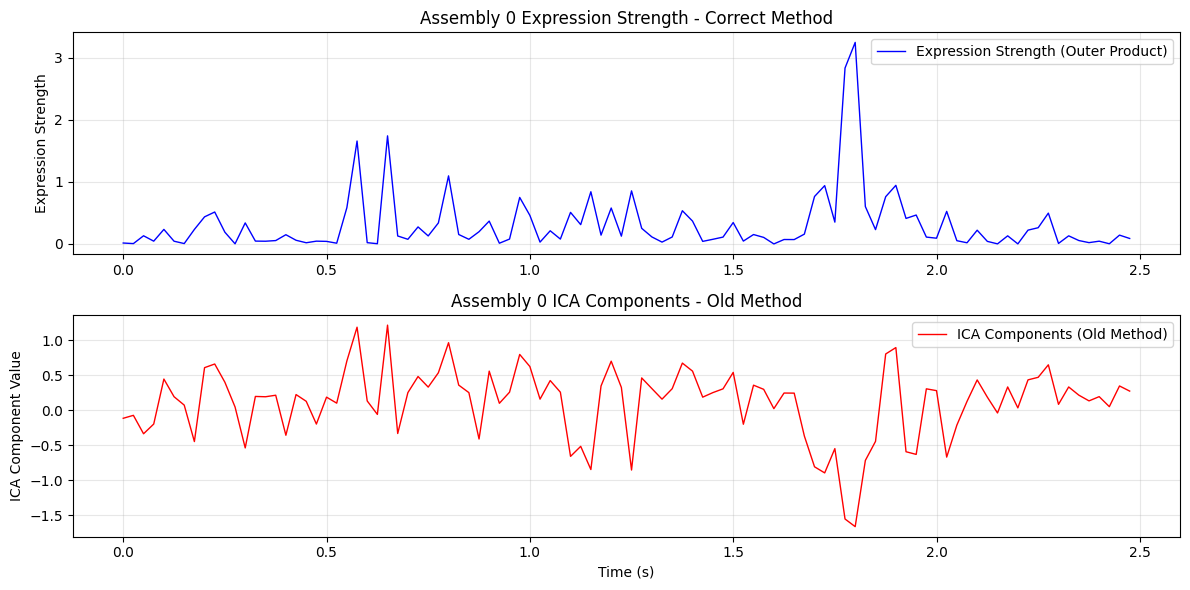


Assembly activation times using correct expression strength (2 std > mean):
Assembly 0: 1235 activations, threshold = 6.423
  First 5 activation times (seconds): [ 3.05   3.475  4.825 10.275 10.75 ]
Assembly 1: 1492 activations, threshold = 5.235
  First 5 activation times (seconds): [1.125 1.15  2.25  2.8   2.85 ]
Assembly 2: 740 activations, threshold = 13.272
  First 5 activation times (seconds): [ 6.375 12.275 12.35  12.45  12.625]
Assembly 3: 1122 activations, threshold = 8.938
  First 5 activation times (seconds): [ 37.175  97.1    99.875 103.7   110.05 ]
Assembly 4: 926 activations, threshold = 8.558
  First 5 activation times (seconds): [ 8.65  50.675 50.725 55.475 64.475]
Assembly 5: 1210 activations, threshold = 7.151
  First 5 activation times (seconds): [37.35  39.375 41.05  43.675 51.05 ]
Assembly 6: 909 activations, threshold = 7.954
  First 5 activation times (seconds): [15.25  17.175 22.55  24.325 24.425]
Assembly 7: 1868 activations, threshold = 5.653
  First 5 activa

In [ ]:
# Correct expression strength calculation using outer product method
def calculate_expression_strength(firingRateMatrix, ap_norm_matrix):
    """
    Calculate expression strength using the method from the paper:
    E(b) = R(b)^T * Oi * R(b)
    where E(b) is the expression of assembly i in time bin b,
    R(b) is the firing rate matrix column for time bin b,
    and Oi is the outer product of the weight vector of assembly i.
    
    Parameters:
    - firingRateMatrix: shape (time_bins, neurons) - z-scored firing rates
    - ap_norm_matrix: shape (n_assemblies, neurons) - normalized assembly patterns
    
    Returns:
    - expression_strength: shape (time_bins, n_assemblies) - expression strength for each assembly at each time bin
    """
    
    n_time_bins, n_neurons = firingRateMatrix.shape
    n_assemblies = ap_norm_matrix.shape[0]
    
    expression_strength = np.zeros((n_time_bins, n_assemblies))
    
    for assembly_idx in range(n_assemblies):
        # Get the weight vector for this assembly
        weight_vector = ap_norm_matrix[assembly_idx, :]  # shape: (n_neurons,)
        
        # Calculate outer product Oi = weight_vector * weight_vector^T
        outer_product = np.outer(weight_vector, weight_vector)  # shape: (n_neurons, n_neurons)
        
        # Calculate expression strength for each time bin
        for time_bin in range(n_time_bins):
            # R(b) is the firing rate vector for time bin b
            firing_rate_vector = firingRateMatrix[time_bin, :]  # shape: (n_neurons,)
            
            # E(b) = R(b)^T * Oi * R(b)
            # This is equivalent to: firing_rate_vector^T @ outer_product @ firing_rate_vector
            expression_strength[time_bin, assembly_idx] = firing_rate_vector.T @ outer_product @ firing_rate_vector
    
    return expression_strength

# Calculate the correct expression strength
print("Calculating expression strength using outer product method...")
expression_strength = calculate_expression_strength(firingRateMatrix, ap_norm_matrix)

print(f"Expression strength shape: {expression_strength.shape}")
print(f"Expression strength range: {np.min(expression_strength):.3f} to {np.max(expression_strength):.3f}")

# Compare with the old method (ICA components)
print(f"\nComparison with ICA components:")
print(f"ICA components shape: {ica_components.shape}")
print(f"ICA components range: {np.min(ica_components):.3f} to {np.max(ica_components):.3f}")

# Plot comparison for first assembly
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Plot first 100 time bins for comparison
time_bins_to_plot = 100
time_vector_plot = np.arange(time_bins_to_plot) * (time_vector_corrected[1] - time_vector_corrected[0])

ax1.plot(time_vector_plot, expression_strength[:time_bins_to_plot, 0], 'b-', label='Expression Strength (Outer Product)', linewidth=1)
ax1.set_ylabel('Expression Strength')
ax1.set_title('Assembly 0 Expression Strength - Correct Method')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(time_vector_plot, ica_components[:time_bins_to_plot, 0], 'r-', label='ICA Components (Old Method)', linewidth=1)
ax2.set_ylabel('ICA Component Value')
ax2.set_xlabel('Time (s)')
ax2.set_title('Assembly 0 ICA Components - Old Method')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find activation times using the correct expression strength
def find_activation_times_correct(expression_strength, assembly_idx=0, threshold_std=2):
    """
    Find times when assembly expression strength is above threshold using correct method
    """
    assembly_expression = expression_strength[:, assembly_idx]
    mean_expression = np.mean(assembly_expression)
    std_expression = np.std(assembly_expression)
    threshold_value = mean_expression + threshold_std * std_expression
    
    activation_times = np.where(assembly_expression > threshold_value)[0]
    return activation_times, threshold_value

# Find activation times for all assemblies using correct method
n_assemblies = expression_strength.shape[1]
activation_offsets_correct = {}

print("\nAssembly activation times using correct expression strength (2 std > mean):")
for i in range(n_assemblies):
    act_times, threshold = find_activation_times_correct(expression_strength, i, 2)
    if len(act_times) > 0:
        # Convert time bins to seconds
        dt = time_vector_corrected[1] - time_vector_corrected[0]
        activation_seconds = act_times * dt
        activation_offsets_correct[i] = activation_seconds
        print(f"Assembly {i}: {len(act_times)} activations, threshold = {threshold:.3f}")
        print(f"  First 5 activation times (seconds): {activation_seconds[:5]}")
    else:
        activation_offsets_correct[i] = []
        print(f"Assembly {i}: No activations")

print(f"\nSummary of activation offsets (correct method):")
for assembly_idx, offsets in activation_offsets_correct.items():
    if len(offsets) > 0:
        print(f"Assembly {assembly_idx}: {len(offsets)} activation events")
        print(f"  Time range: {offsets[0]:.3f} to {offsets[-1]:.3f} seconds")
        print(f"  First 10 offsets: {offsets[:10]}")
    else:
        print(f"Assembly {assembly_idx}: No activations")
    print()

Finding longest sustained activation periods for each assembly...
Analyzing 10s windows for longest sustained activation...
Window duration: 10000 bins

Analyzing Assembly 0:
  Threshold: 6.423 (mean + 2*std)
  Found 1026 sustained activation segments
  Longest sustained activation: 0.012s
  Time range: 497.517s to 497.792s
  Best offset for 10s window: 492.667s

Analyzing Assembly 1:
  Threshold: 5.235 (mean + 2*std)
  Found 1417 sustained activation segments
  Longest sustained activation: 0.003s
  Time range: 765.492s to 765.542s
  Best offset for 10s window: 760.517s

Analyzing Assembly 2:
  Threshold: 13.272 (mean + 2*std)
  Found 649 sustained activation segments
  Longest sustained activation: 0.005s
  Time range: 789.417s to 789.517s
  Best offset for 10s window: 784.467s

Analyzing Assembly 3:
  Threshold: 8.938 (mean + 2*std)
  Found 837 sustained activation segments
  Longest sustained activation: 0.011s
  Time range: 546.042s to 546.292s
  Best offset for 10s window: 541.16

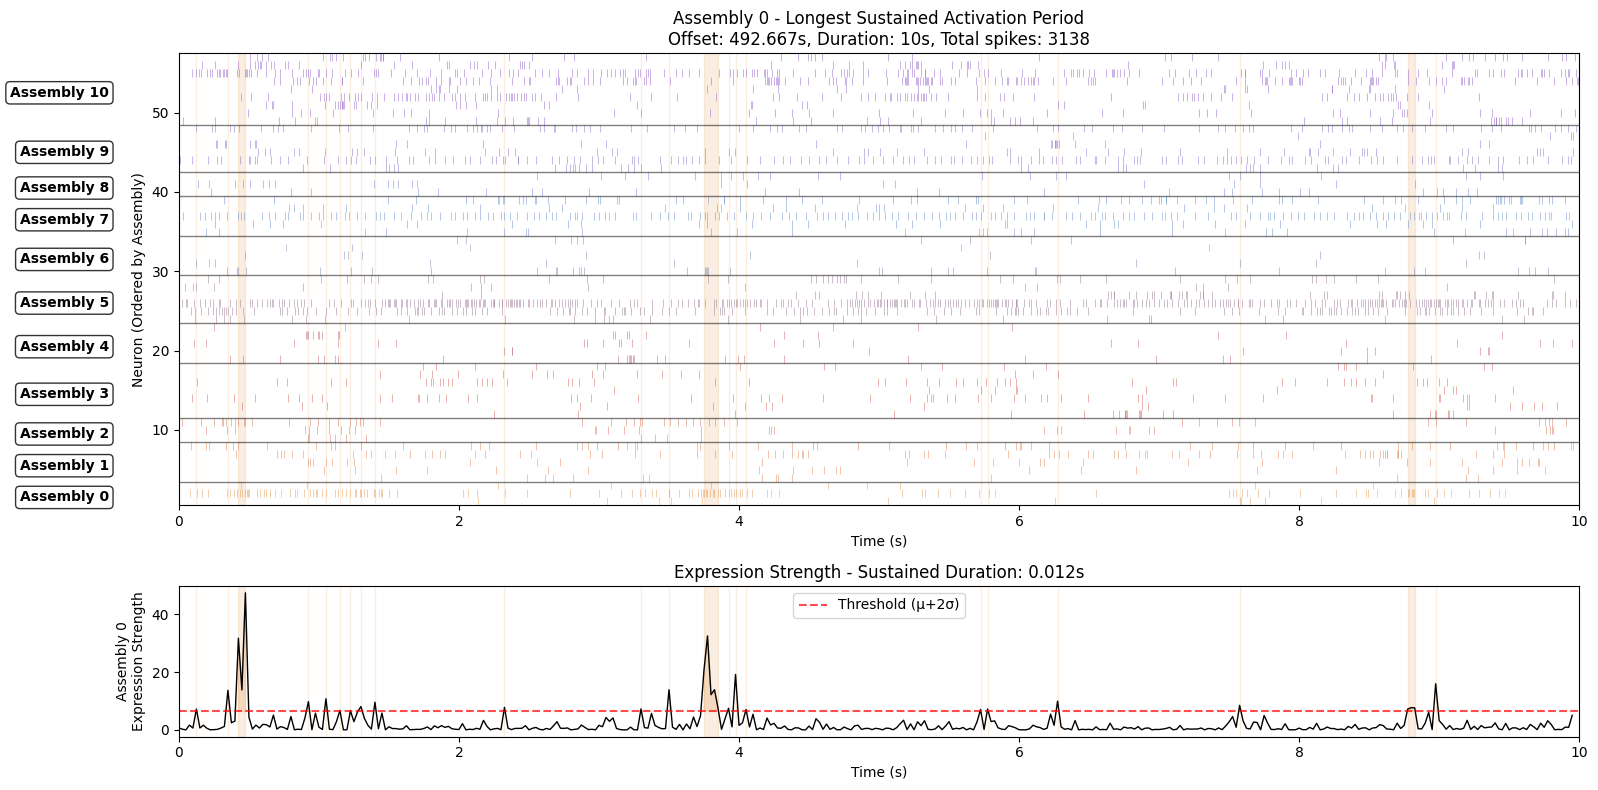

Total spikes plotted: 3138
Sustained duration: 0.012s

Plotting Assembly 1:
Plotting Assembly 1 at best offset: 760.517s


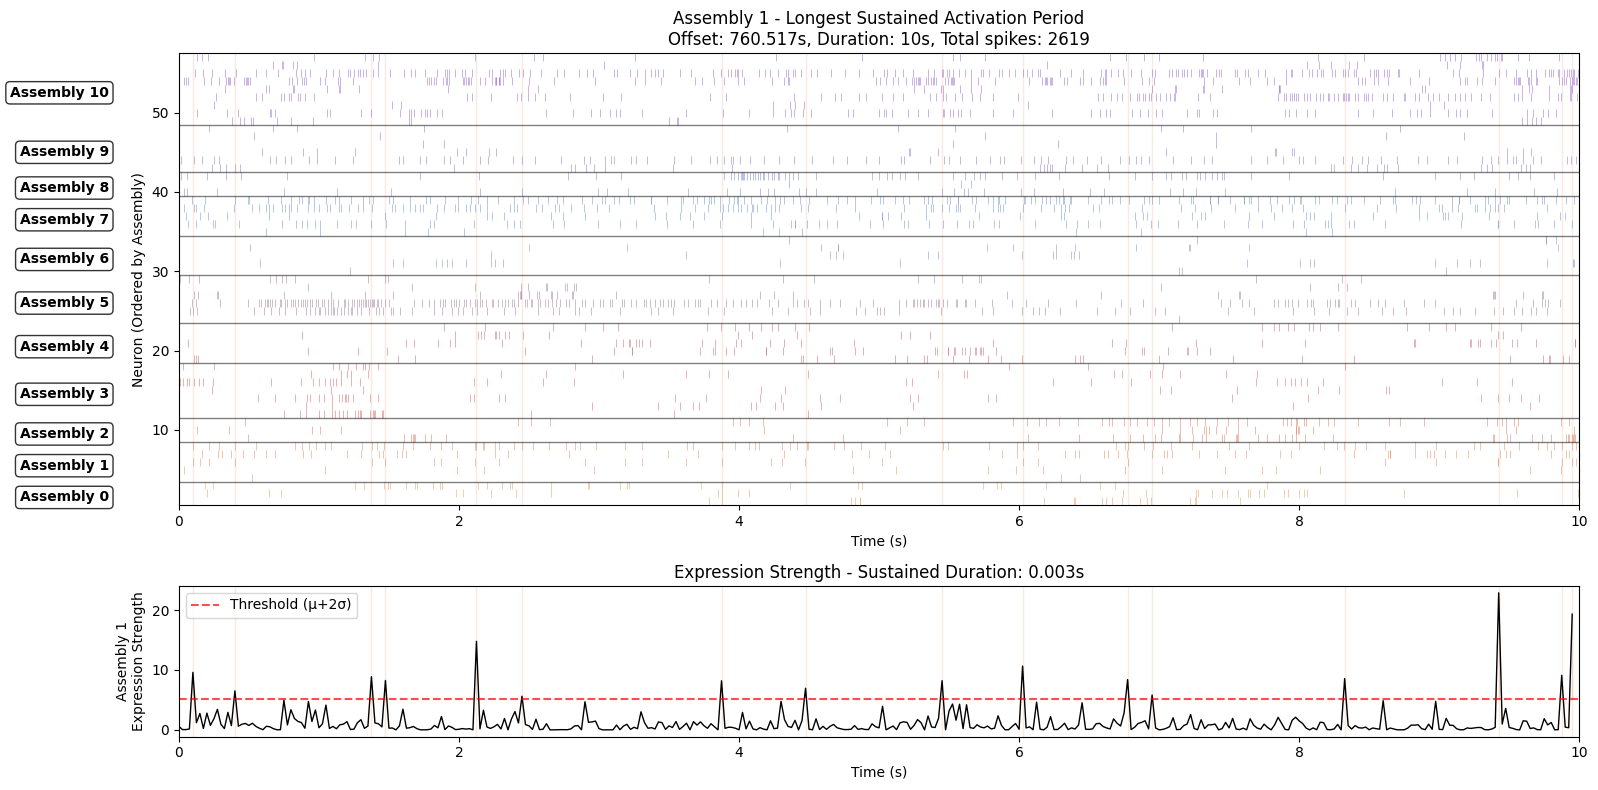

Total spikes plotted: 2619
Sustained duration: 0.003s

Plotting Assembly 2:
Plotting Assembly 2 at best offset: 784.467s


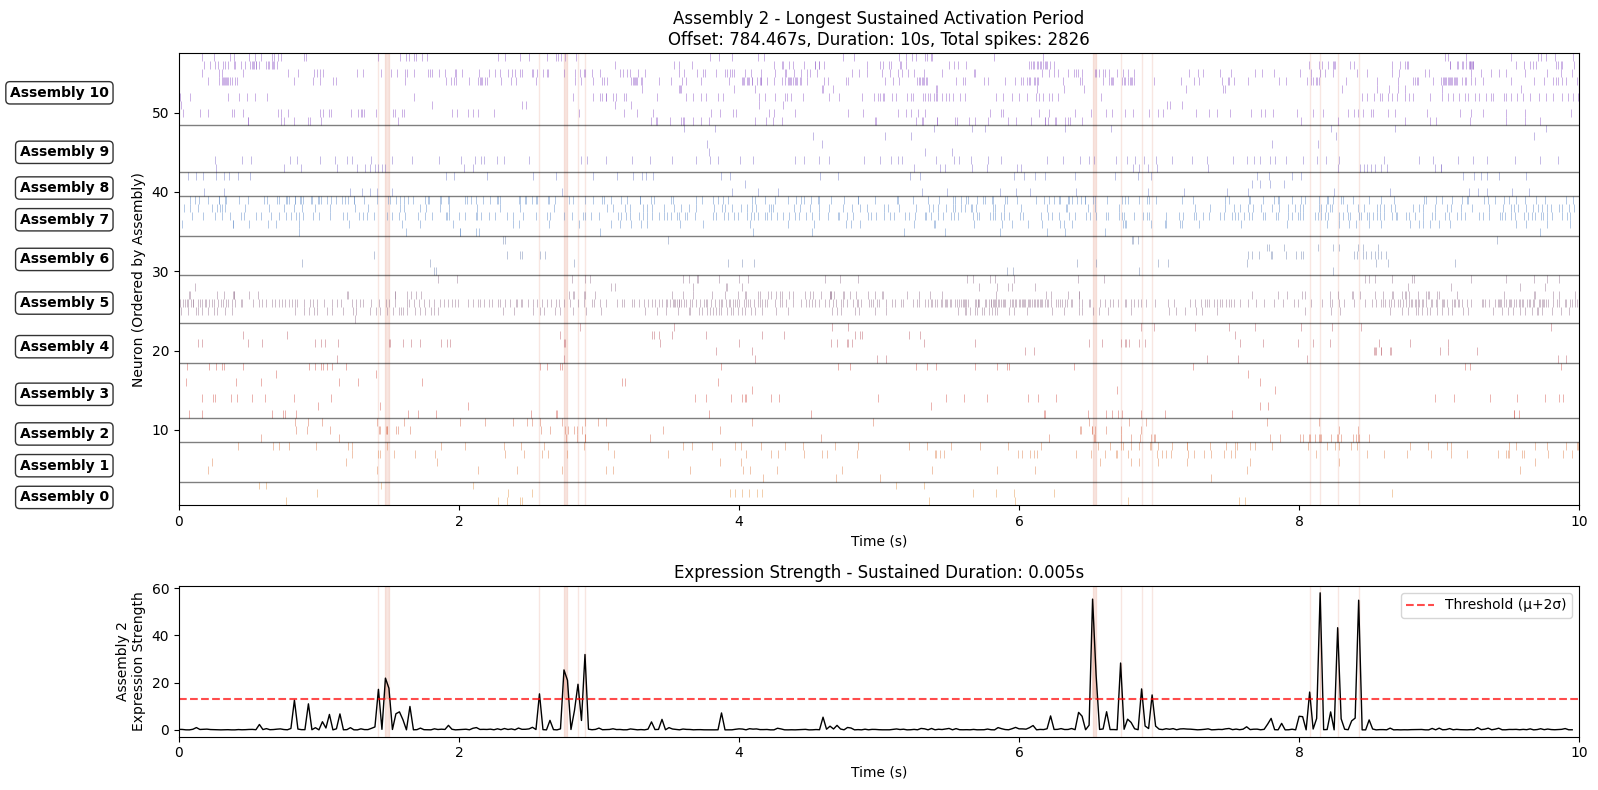

Total spikes plotted: 2826
Sustained duration: 0.005s

Plotting Assembly 3:
Plotting Assembly 3 at best offset: 541.167s


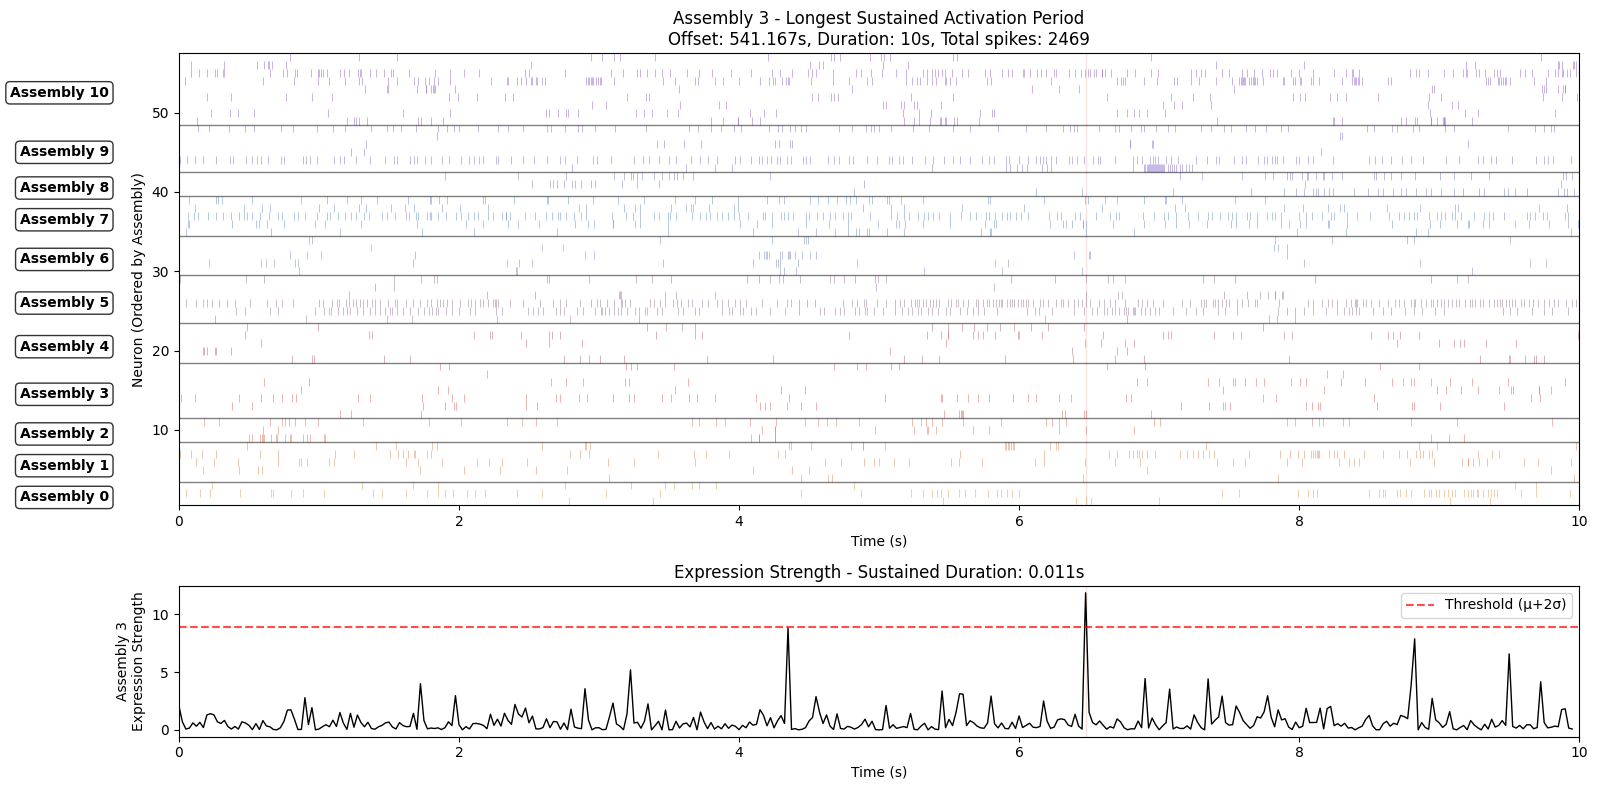

Total spikes plotted: 2469
Sustained duration: 0.011s

Plotting Assembly 4:
Plotting Assembly 4 at best offset: 849.017s


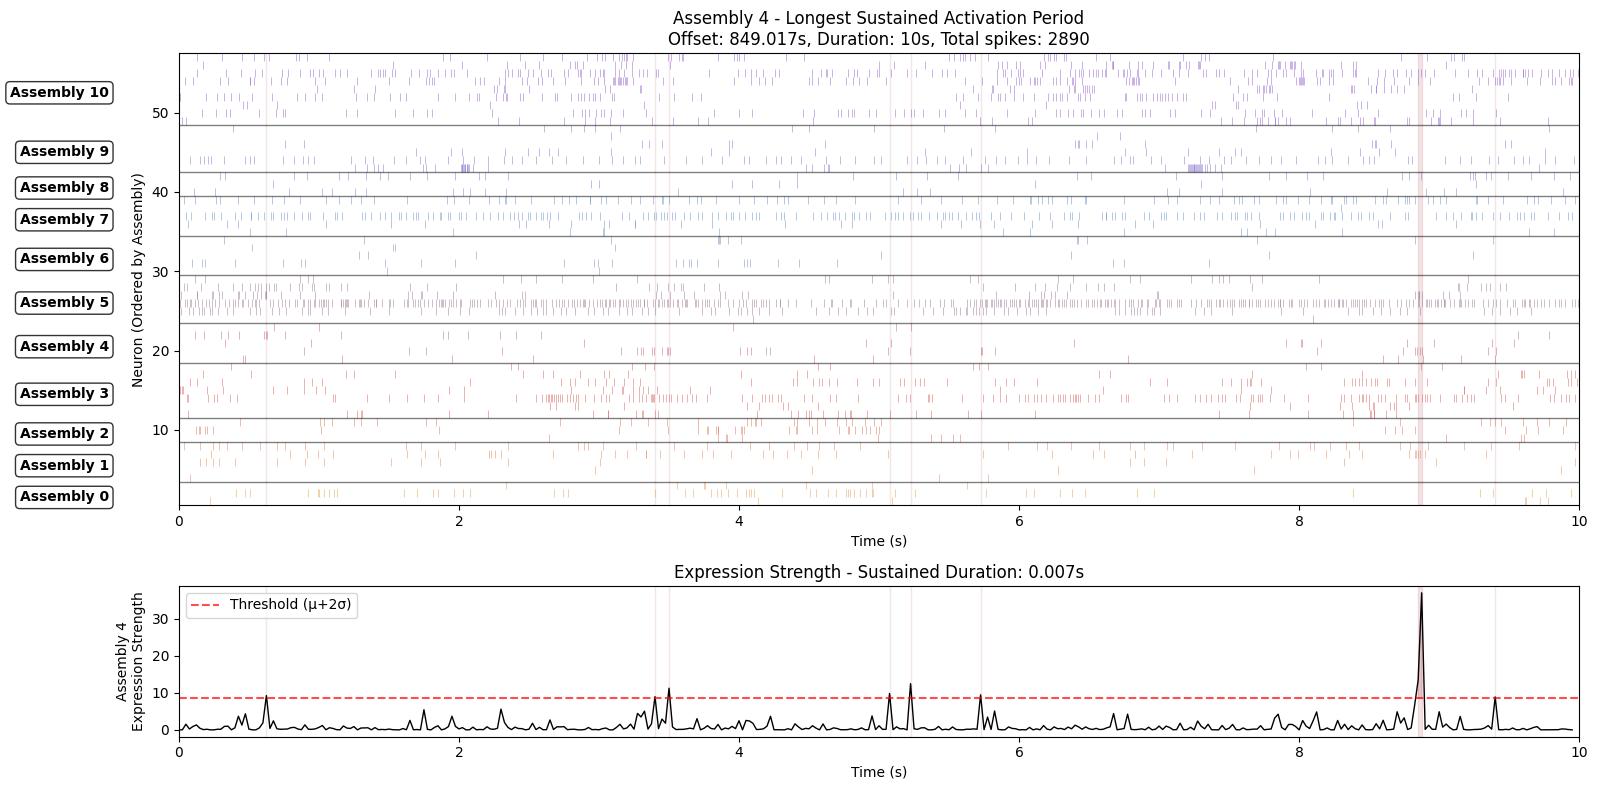

Total spikes plotted: 2890
Sustained duration: 0.007s

Plotting Assembly 5:
Plotting Assembly 5 at best offset: 971.517s


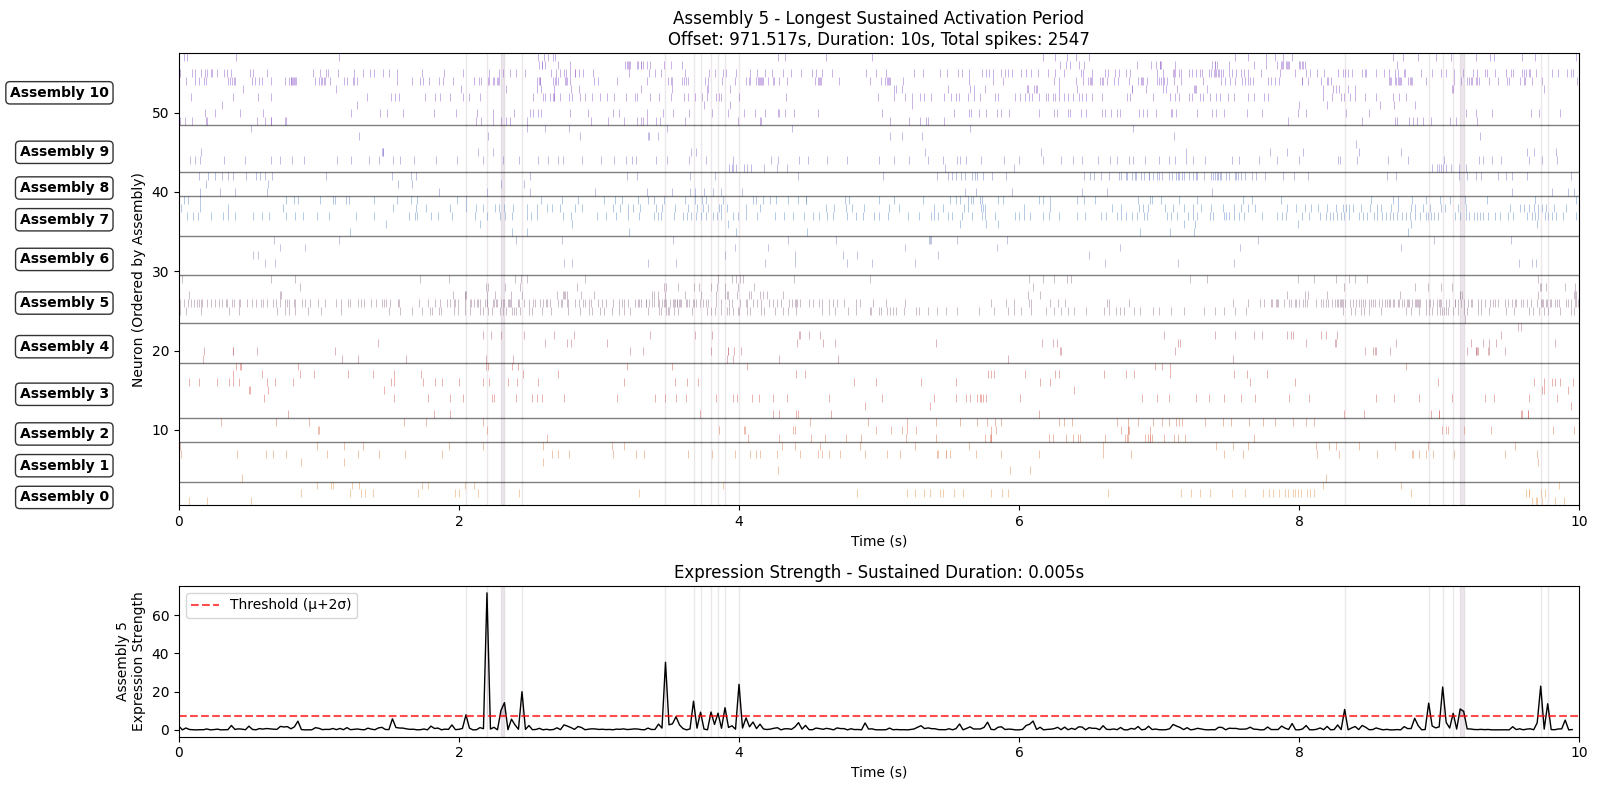

Total spikes plotted: 2547
Sustained duration: 0.005s

Plotting Assembly 6:
Plotting Assembly 6 at best offset: 916.542s


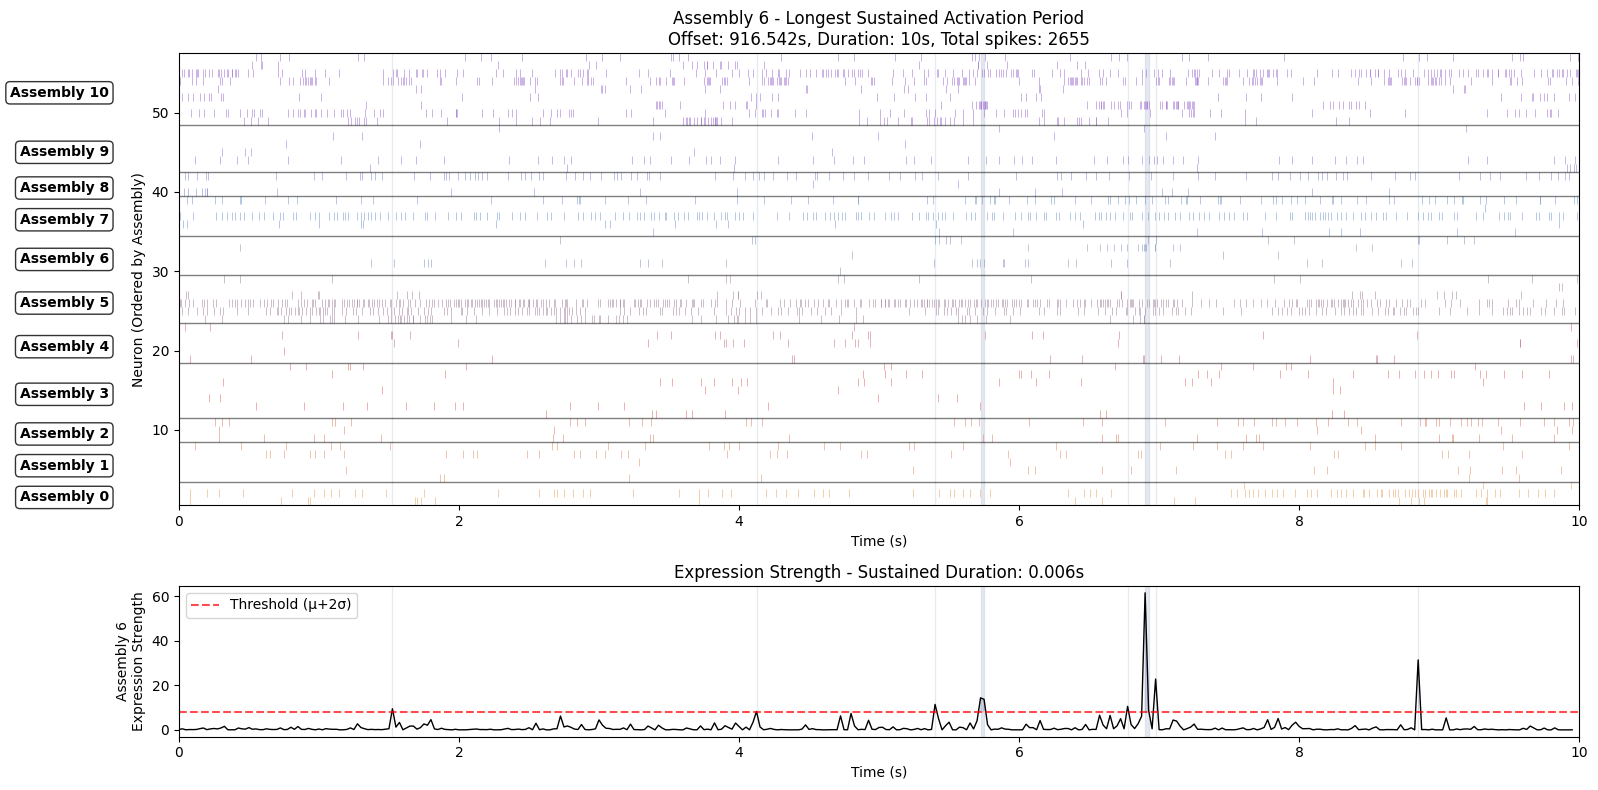

Total spikes plotted: 2655
Sustained duration: 0.006s

Plotting Assembly 7:
Plotting Assembly 7 at best offset: 337.342s


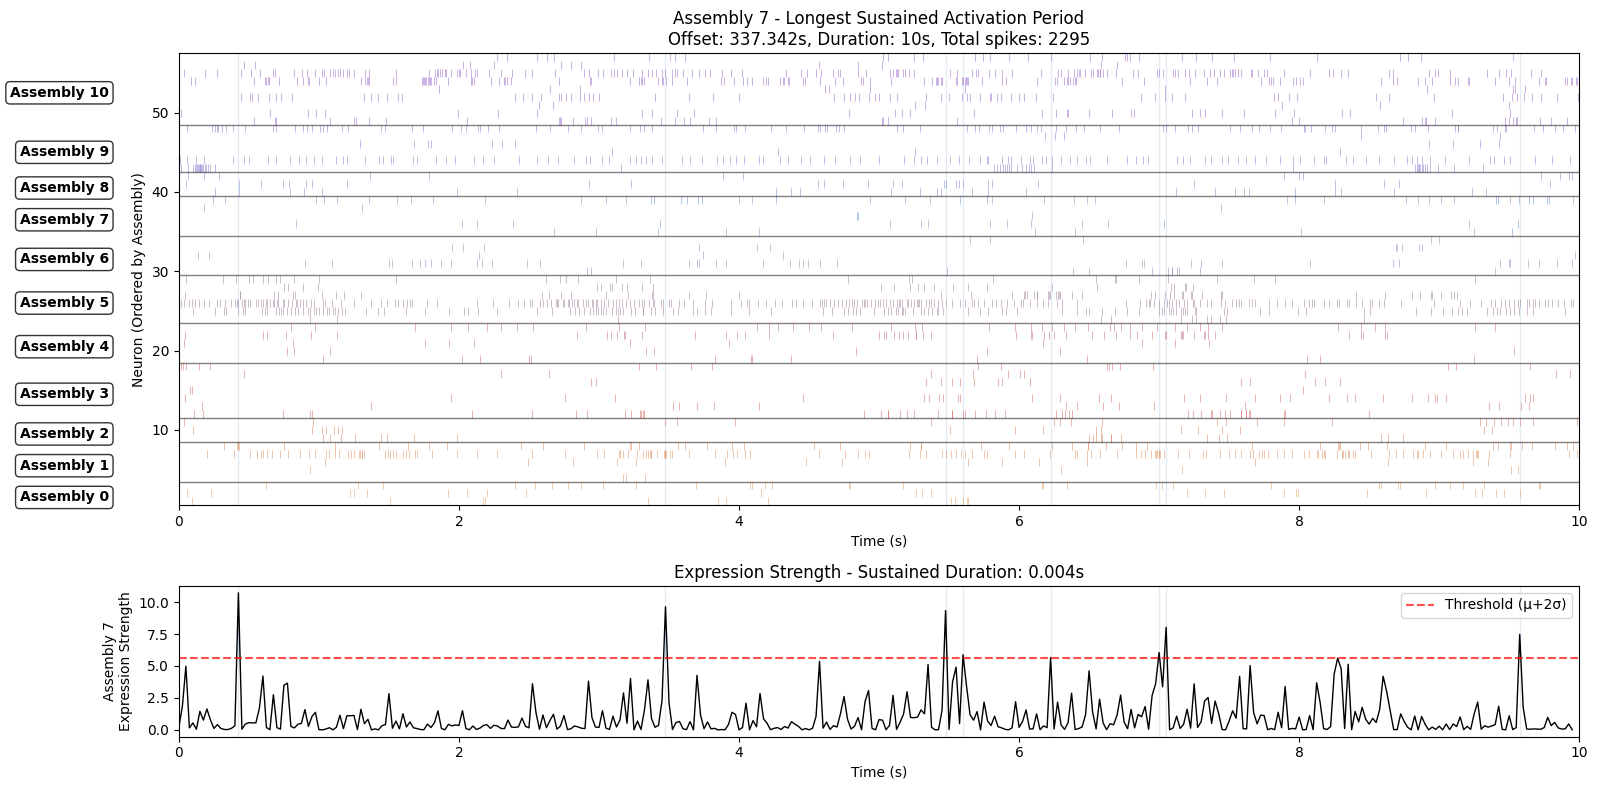

Total spikes plotted: 2295
Sustained duration: 0.004s

Plotting Assembly 8:
Plotting Assembly 8 at best offset: 244.592s


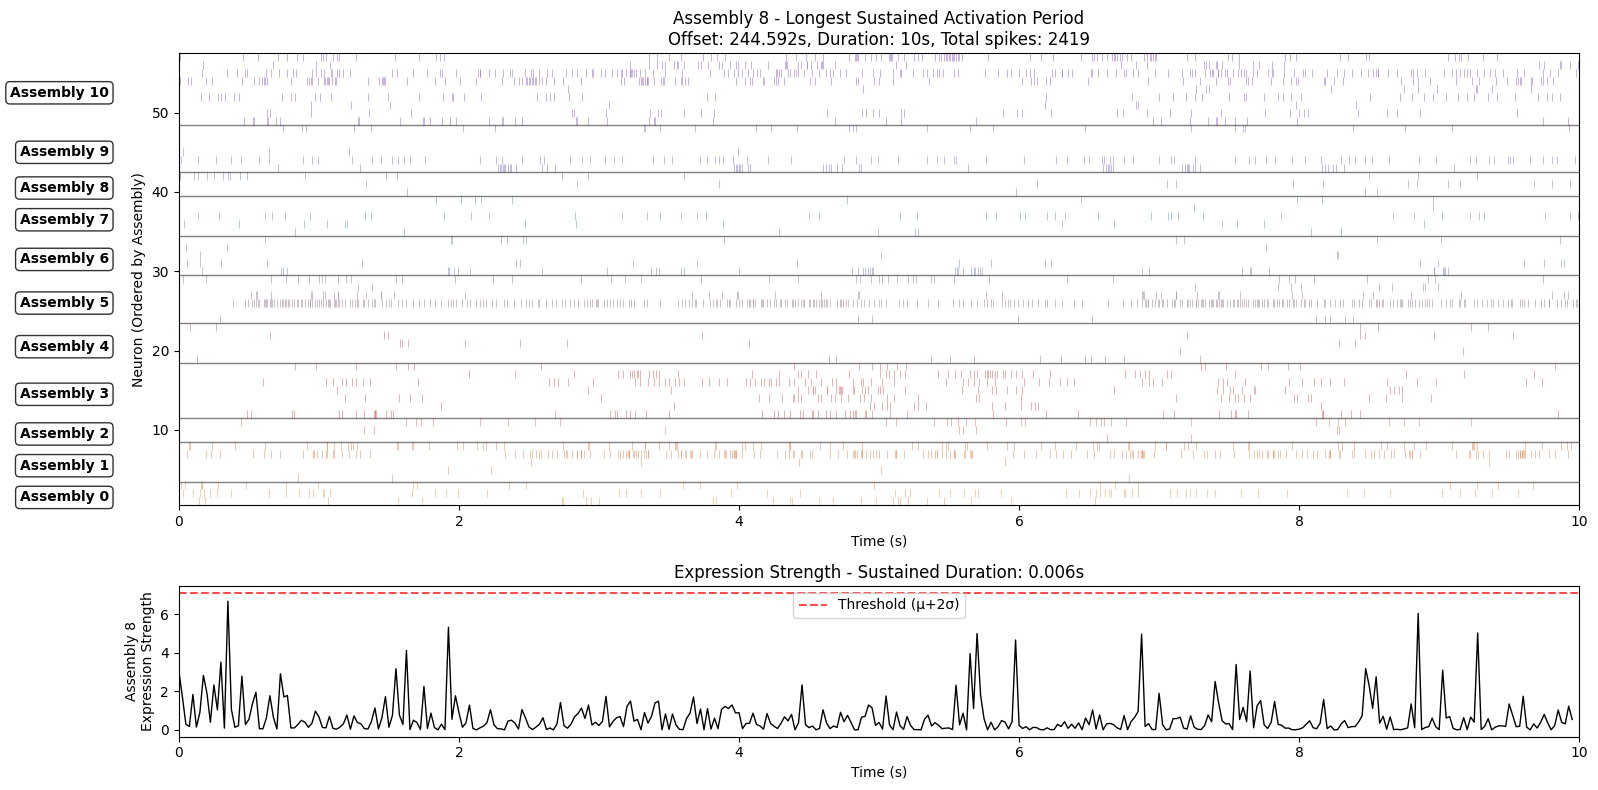

Total spikes plotted: 2419
Sustained duration: 0.006s

Plotting Assembly 9:
Plotting Assembly 9 at best offset: 722.167s


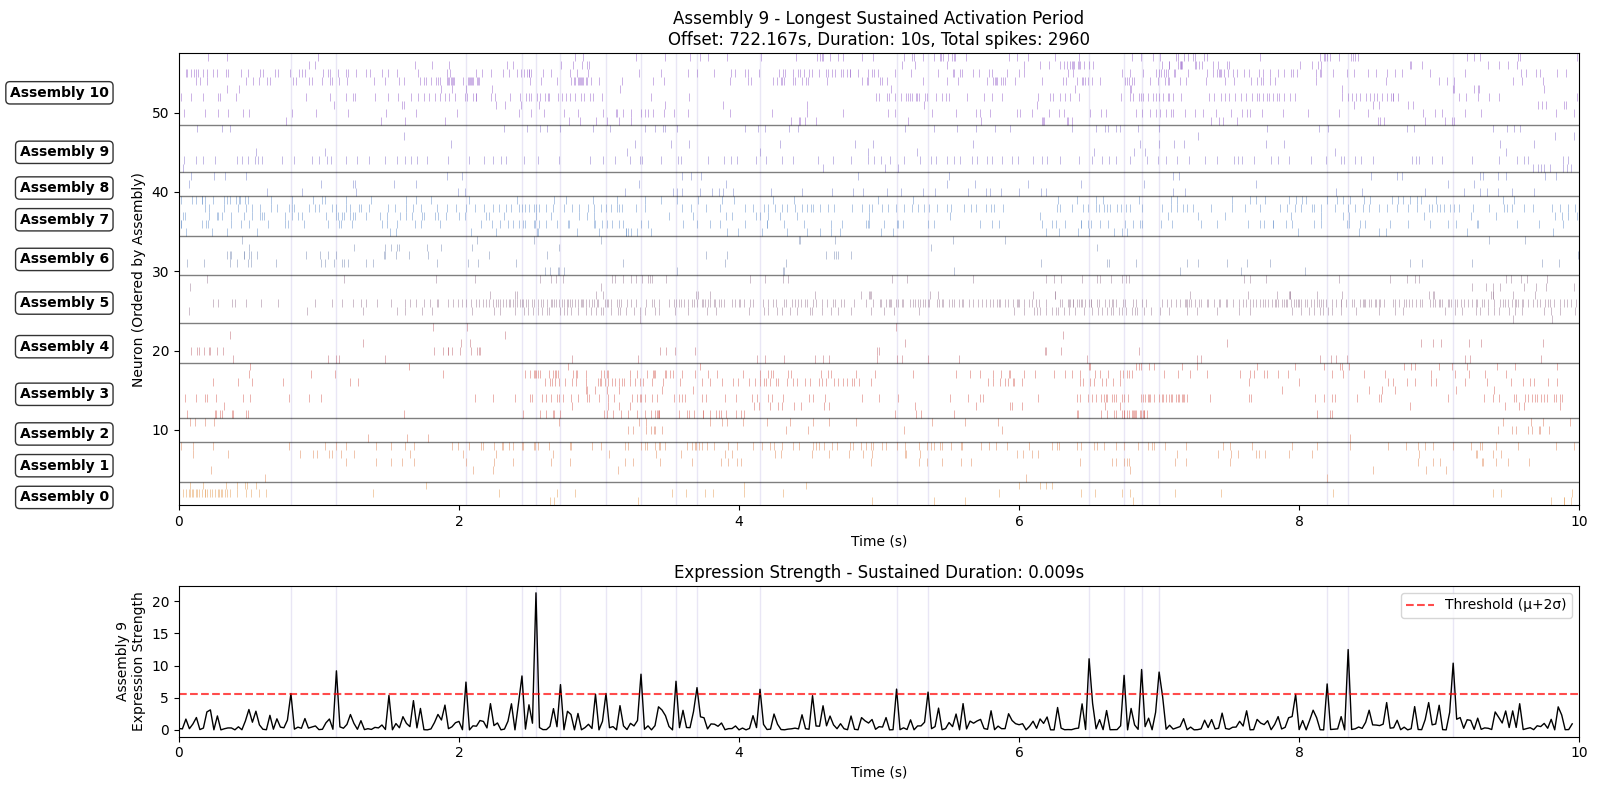

Total spikes plotted: 2960
Sustained duration: 0.009s

Plotting Assembly 10:
Plotting Assembly 10 at best offset: 394.892s


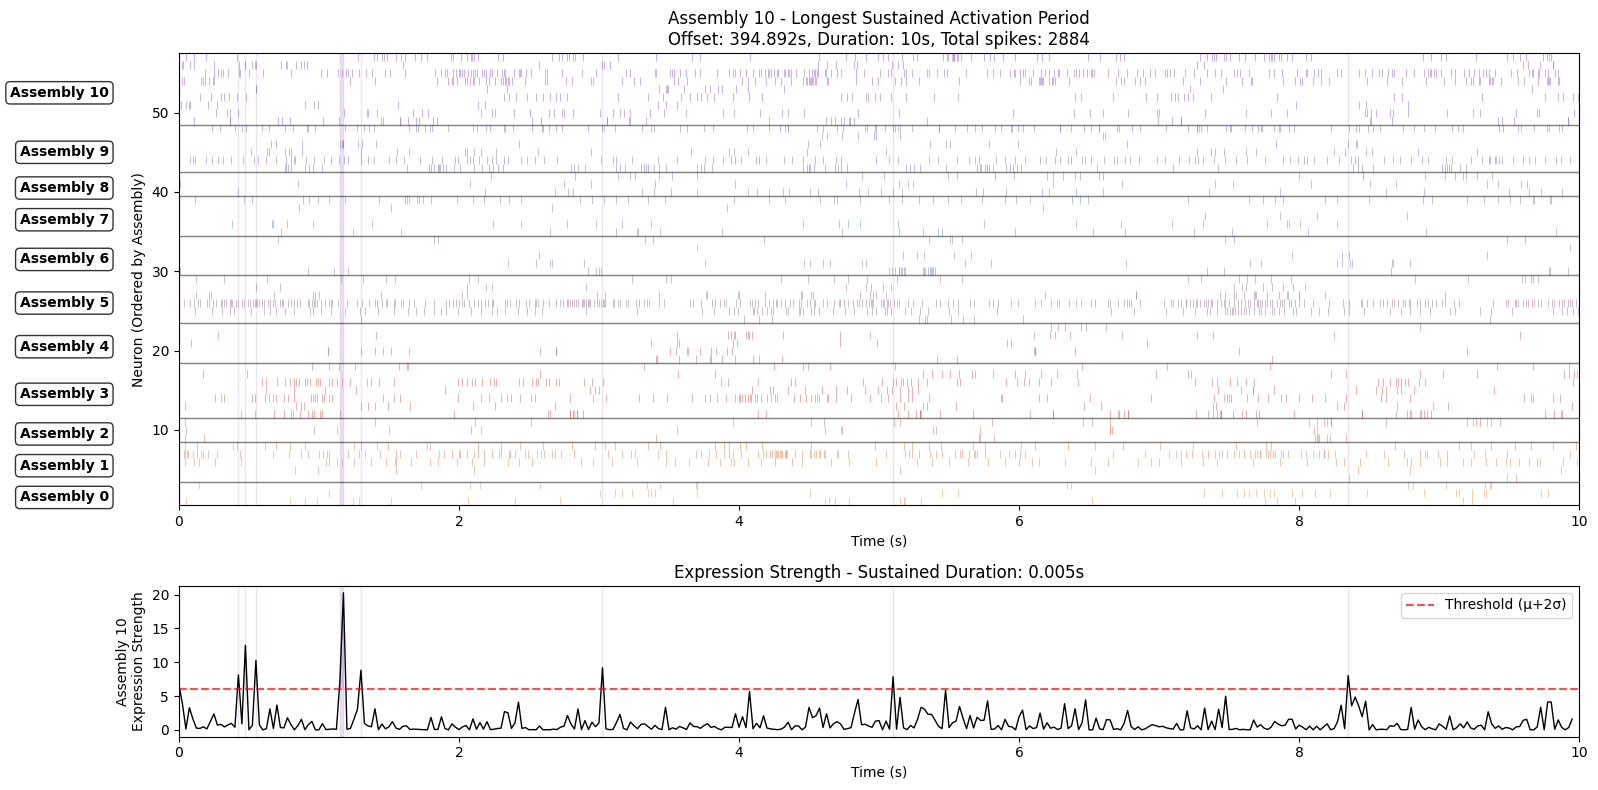

Total spikes plotted: 2884
Sustained duration: 0.005s


In [49]:
# Find longest sustained expression strength for each assembly
plt.rcParams['svg.fonttype'] = 'none' 
def find_longest_sustained_activation(expression_strength, time_vector_corrected, 
                                     threshold_std=2, window_duration=10):
    """
    Find the offset time for each assembly that has the longest sustained 
    expression strength > threshold in a specified window duration.
    
    Parameters:
    - expression_strength: shape (time_bins, n_assemblies)
    - time_vector_corrected: time vector in seconds
    - threshold_std: number of standard deviations above mean for threshold
    - window_duration: duration of window to analyze (seconds)
    
    Returns:
    - best_offsets: dict with assembly_idx as key and best offset time as value
    - sustained_durations: dict with assembly_idx as key and duration of sustained activation
    """
    
    n_assemblies = expression_strength.shape[1]
    dt = time_vector[1] - time_vector[0]
    window_bins = int(window_duration / dt)
    
    best_offsets = {}
    sustained_durations = {}
    
    print(f"Analyzing {window_duration}s windows for longest sustained activation...")
    print(f"Window duration: {window_bins} bins")
    
    for assembly_idx in range(n_assemblies):
        print(f"\nAnalyzing Assembly {assembly_idx}:")
        
        # Get expression strength for this assembly
        assembly_expression = expression_strength[:, assembly_idx]
        
        # Calculate threshold
        mean_expression = np.mean(assembly_expression)
        std_expression = np.std(assembly_expression)
        threshold = mean_expression + threshold_std * std_expression
        
        print(f"  Threshold: {threshold:.3f} (mean + {threshold_std}*std)")
        
        # Find all time bins where expression > threshold
        above_threshold = assembly_expression > threshold
        
        # Find continuous segments above threshold
        # Use np.diff to find transitions
        diff = np.diff(above_threshold.astype(int))
        starts = np.where(diff == 1)[0] + 1  # +1 because diff shifts indices
        ends = np.where(diff == -1)[0] + 1
        
        # Handle edge cases
        if above_threshold[0]:  # If starts above threshold
            starts = np.concatenate([[0], starts])
        if above_threshold[-1]:  # If ends above threshold
            ends = np.concatenate([ends, [len(above_threshold)]])
        
        # Calculate durations of sustained activations
        sustained_segments = []
        for start, end in zip(starts, ends):
            duration_bins = end - start
            duration_seconds = duration_bins * dt
            sustained_segments.append({
                'start_bin': start,
                'end_bin': end,
                'start_time': time_vector_corrected[start],
                'end_time': time_vector_corrected[end-1] if end < len(time_vector_corrected) else time_vector_corrected[-1],
                'duration_seconds': duration_seconds,
                'duration_bins': duration_bins
            })
        
        print(f"  Found {len(sustained_segments)} sustained activation segments")
        
        # Find the longest sustained activation
        if sustained_segments:
            longest_segment = max(sustained_segments, key=lambda x: x['duration_seconds'])
            
            # Find the best offset within this segment for a window_duration window
            segment_start_bin = longest_segment['start_bin']
            segment_end_bin = longest_segment['end_bin']
            segment_duration_bins = longest_segment['duration_bins']
            
            if segment_duration_bins >= window_bins:
                # The segment is long enough for the full window
                # Use the start of the segment as the offset
                best_offset = longest_segment['start_time']
                best_duration = window_duration
            else:
                # The segment is shorter than the window
                # Use the center of the segment as the offset
                segment_center_bin = (segment_start_bin + segment_end_bin) // 2
                best_offset = time_vector_corrected[segment_center_bin] - window_duration/2
                best_offset = max(0, best_offset)  # Don't go below 0
                best_duration = longest_segment['duration_seconds']
            
            best_offsets[assembly_idx] = best_offset
            sustained_durations[assembly_idx] = longest_segment['duration_seconds']
            
            print(f"  Longest sustained activation: {longest_segment['duration_seconds']:.3f}s")
            print(f"  Time range: {longest_segment['start_time']:.3f}s to {longest_segment['end_time']:.3f}s")
            print(f"  Best offset for {window_duration}s window: {best_offset:.3f}s")
            
        else:
            print(f"  No sustained activations found above threshold")
            best_offsets[assembly_idx] = None
            sustained_durations[assembly_idx] = 0
    
    return best_offsets, sustained_durations

# Find best offsets for all assemblies
print("Finding longest sustained activation periods for each assembly...")
best_offsets, sustained_durations = find_longest_sustained_activation(
    expression_strength, time_vector_corrected, threshold_std=2, window_duration=10
)

# Print summary
print(f"\nSummary of best offsets for 10s windows:")
for assembly_idx in range(len(best_offsets)):
    if best_offsets[assembly_idx] is not None:
        print(f"Assembly {assembly_idx}:")
        print(f"  Best offset: {best_offsets[assembly_idx]:.3f}s")
        print(f"  Sustained duration: {sustained_durations[assembly_idx]:.3f}s")
    else:
        print(f"Assembly {assembly_idx}: No sustained activations found")

# Function to plot spike raster at best offset
def plot_spike_raster_best_offset(
    assembly_idx, 
    window_duration=10, 
    best_offsets=best_offsets,
    spike_times_good=spike_times_good, 
    expression_strength=expression_strength,
    ap_norm_matrix=ap_norm_matrix,
    time_vector=time_vector_corrected,
    indicesFinal=indicesFinal,
    custom_colors=['#E69F5B', '#D66060', '#6699CC', '#9966CC'],
    aspect_ratio=None
):
    """
    Plot spike raster at the best offset for longest sustained activation

    Parameters:
    - assembly_idx: index of the assembly to plot
    - window_duration: duration of time window for plot (seconds)
    - best_offsets, spike_times_good, expression_strength, etc: same as before
    - aspect_ratio: Optional. Desired aspect ratio (width / height) for the figure. 
                    If set, the figure size will be adjusted accordingly. 
                    If None, defaults to figsize=(16, 8).
    """
    
    if best_offsets[assembly_idx] is None:
        print(f"Assembly {assembly_idx} has no sustained activations above threshold")
        return None
    
    offset_seconds = best_offsets[assembly_idx]
    print(f"Plotting Assembly {assembly_idx} at best offset: {offset_seconds:.3f}s")
    
    # Get assembly expression strength (correct method)
    assembly_expression = expression_strength[:, assembly_idx]
    
    # Convert offset to time bins
    dt = time_vector[1] - time_vector[0]
    offset_bins = int(offset_seconds / dt)
    start_bin = offset_bins
    end_bin = min(start_bin + int(window_duration / dt), len(time_vector))
    
    # Get time window
    time_window = time_vector[start_bin:end_bin]
    expression_window = assembly_expression[start_bin:end_bin]
    t_start = time_vector[start_bin]
    
    # Get the above-threshold mask for the current window
    threshold = np.mean(assembly_expression) + 2 * np.std(assembly_expression)
    above_threshold_mask = expression_window > threshold

    # For shading, get intervals of consecutive above-threshold times in the window
    def get_consecutive_intervals(mask, base_time_array):
        # mask: boolean for e.g. above-threshold
        # base_time_array: 1D array of times
        intervals = []
        diff = np.diff(mask.astype(int))
        start_idxs = np.where(diff == 1)[0] + 1
        end_idxs = np.where(diff == -1)[0] + 1

        # Handle edge cases
        if mask[0]:
            start_idxs = np.concatenate([[0], start_idxs])
        if mask[-1]:
            end_idxs = np.concatenate([end_idxs, [len(mask)]])
        # Now create intervals
        for start, end in zip(start_idxs, end_idxs):
            intervals.append((base_time_array[start], base_time_array[end-1] if end-1 < len(base_time_array) else base_time_array[-1]))
        return intervals

    above_thr_intervals = get_consecutive_intervals(above_threshold_mask, time_window-t_start)

    # Create figure with subplots, supporting custom aspect ratio
    if aspect_ratio is not None:
        # Target height such that width / height = aspect_ratio, keeping width default as 16
        base_width = 16
        width = base_width
        height = base_width / aspect_ratio
        fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(width, height), 
            gridspec_kw={'height_ratios': [3, 1]}
        )
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Get assembly membership
    neuron_assembly_membership = np.argmax(ap_norm_matrix[:, :], axis=0)
    unique_assemblies = np.unique(neuron_assembly_membership)
    
    # Create gradient colormap with darker colors
    from matplotlib.colors import LinearSegmentedColormap
    gradient_cmap = LinearSegmentedColormap.from_list('darker_gradient', custom_colors, N=256)
    
    # Create color mapping with gradient
    assembly_color_map = {}
    for i, assembly in enumerate(unique_assemblies):
        gradient_position = i / (len(unique_assemblies) - 1) if len(unique_assemblies) > 1 else 0
        color = gradient_cmap(gradient_position)
        assembly_color_map[assembly] = color
    
    # Order neurons by assembly membership
    neuron_assembly_pairs = []
    for neuron_idx in indicesFinal:
        neuron_idx_in_matrix = list(indicesFinal).index(neuron_idx)
        assembly_membership = neuron_assembly_membership[neuron_idx_in_matrix]
        neuron_assembly_pairs.append((neuron_idx, assembly_membership))
    
    neuron_assembly_pairs.sort(key=lambda x: (x[1], x[0]))
    ordered_neuron_indices = [pair[0] for pair in neuron_assembly_pairs]

    # Highlight periods of assembly expression strength > threshold on raster using the color matching assembly's raster color
    y0_raster = 0.5
    y1_raster = len(spike_times_good) + 0.5
    highlight_color = assembly_color_map[assembly_idx]

    for interval_start, interval_end in above_thr_intervals:
        ax1.axvspan(interval_start, interval_end, color=highlight_color, alpha=0.18, zorder=0)
    
    # Plot spikes in assembly order
    n_neurons = len(spike_times_good)
    total_spikes_plotted = 0
    
    for plot_idx, neuron_idx in enumerate(ordered_neuron_indices):
        st = spike_times_good[neuron_idx]
        spike_times_sec = st.as_series().index
        spike_times_plot = spike_times_sec[(spike_times_sec >= t_start) & (spike_times_sec < t_start + window_duration)]
        
        if len(spike_times_plot) > 0:
            spike_times_normalized = spike_times_plot - t_start
            neuron_idx_in_matrix = list(indicesFinal).index(neuron_idx)
            assembly_membership = neuron_assembly_membership[neuron_idx_in_matrix]
            color = assembly_color_map[assembly_membership]
            
            ax1.vlines(spike_times_normalized, plot_idx + 0.5, plot_idx + 1.5, 
                       color=color, linewidth=0.5, alpha=0.7)
            total_spikes_plotted += len(spike_times_plot)
    
    # Format plots
    ax1.set_ylabel('Neuron (Ordered by Assembly)')
    ax1.set_xlabel('Time (s)')
    ax1.set_title(f'Assembly {assembly_idx} - Longest Sustained Activation Period\n'
                  f'Offset: {offset_seconds:.3f}s, Duration: {window_duration}s, '
                  f'Total spikes: {total_spikes_plotted}')
    ax1.set_ylim(0.5, n_neurons + 0.5)
    ax1.set_xlim(0, window_duration)

    # Add assembly boundaries and labels
    current_assembly = None
    assembly_start = 0
    for plot_idx, (neuron_idx, assembly_membership) in enumerate(neuron_assembly_pairs):
        if current_assembly is None:
            current_assembly = assembly_membership
            assembly_start = plot_idx
        elif assembly_membership != current_assembly:
            ax1.axhline(y=plot_idx + 0.5, color='black', linewidth=1, alpha=0.5)
            assembly_center = (assembly_start + plot_idx) / 2
            ax1.text(-window_duration * 0.05, assembly_center, f'Assembly {current_assembly}', 
                    ha='right', va='center', fontsize=10, fontweight='bold', 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            current_assembly = assembly_membership
            assembly_start = plot_idx
    
    # Add label for last assembly
    if current_assembly is not None:
        assembly_center = (assembly_start + n_neurons) / 2
        ax1.text(-window_duration * 0.05, assembly_center, f'Assembly {current_assembly}', 
                ha='right', va='center', fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Highlight the same above-threshold periods in the lower plot using the same color as above 
    for interval_start, interval_end in above_thr_intervals:
        ax2.axvspan(interval_start, interval_end, color=highlight_color, alpha=0.18, zorder=0)
    
    # Plot assembly expression strength
    ax2.plot(time_window - t_start, expression_window, color='black', linewidth=1)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(f'Assembly {assembly_idx}\nExpression Strength')
    ax2.set_title(f'Expression Strength - Sustained Duration: {sustained_durations[assembly_idx]:.3f}s')
    ax2.set_xlim(0, window_duration)
    
    # Add threshold line
    ax2.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, 
                label=f'Threshold (μ+2σ)')
    ax2.legend()

    # Optionally, fill area above threshold on the bottom plot using the same color
    ax2.fill_between(time_window - t_start, threshold, expression_window, 
                     where=(expression_window > threshold), alpha=0.25, color=highlight_color, 
                     label='Above Threshold')

    plt.tight_layout()
    plt.show()
    
    print(f"Total spikes plotted: {total_spikes_plotted}")
    print(f"Sustained duration: {sustained_durations[assembly_idx]:.3f}s")
    
    return fig

# Test plotting at best offsets
print("\nPlotting spike rasters at best offsets for longest sustained activation:")

for assembly_idx in range(len(best_offsets)):
    if best_offsets[assembly_idx] is not None:
        print(f"\nPlotting Assembly {assembly_idx}:")
        # You can now set custom aspect ratio in the function call below, e.g. aspect_ratio=2.0 for twice-as-wide-as-tall
        fig = plot_spike_raster_best_offset(assembly_idx, window_duration=10, aspect_ratio=2)
        # Save the figure as an SVG file
        fig.savefig(f"assembly_{assembly_idx}_spike_raster.svg", format='svg')
        